# Observador: spider-level EDA

Fixed sections:
1. Run selection and player evidence
2. Volume, temporal coverage, and quality overview
3. Text-length histograms by original_label and standard_label
4. Category, topic/tag, and temporal distribution
5. Missing fields and invalid dates
6. Cleaning and normalization review
7. NLP with stop-word removal, lemmas, and NER
8. Processed JSONL export


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().resolve().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Repositorio nao encontrado a partir do diretorio atual.")


REPO_ROOT = _find_repo_root()
for path in (REPO_ROOT, REPO_ROOT / "src", REPO_ROOT / "notebooks"):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import eda_utils as eu

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", palette="crest")

## Run selection and player evidence

In [2]:
SPIDER = "observador"
PLAYER = "Observador"
DATA_DIR = eu.resolve_data_dir(str(REPO_ROOT / "data"))
SNAPSHOT_ID = None
BATCH_SIZE = 64

selection = eu.select_spider_run(DATA_DIR, SPIDER)
profile = eu.get_spider_profile(SPIDER)
display(eu.selection_to_frame(selection))
profile

,spider,agency_id,agency_name,selected_run_id,latest_run_id,latest_valid_run_id,fallback_applied,selection_reason,cleaning_flags,diagnostic_run_ids
0,observador,observador,Observador,20260315T143549Z-8506cab9,20260315T143549Z-8506cab9,20260315T143549Z-8506cab9,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix, ignore_generic_title_in_analysis, claim_summary_priority",


SpiderProfile(spider='observador', display_name='Observador', analysis_field_order=('claim', 'summary', 'title'), ignored_analysis_titles=frozenset({'observador'}), dropped_export_titles=frozenset(), extract_label_prefix_before_colon=False, diagnostic_run_ids=(), cleaning_flags=('html_unescape', 'unicode_normalize', 'collapse_whitespace', 'light_encoding_fix', 'ignore_generic_title_in_analysis', 'claim_summary_priority'))

In [3]:
runs_df = eu.load_runs_df(DATA_DIR)
spider_runs = runs_df.loc[runs_df["spider"] == SPIDER].sort_values(
    "run_started_at", ascending=False
)
evidence_cols = [
    "run_id",
    "run_started_at",
    "run_finished_at",
    "items_seen",
    "items_stored",
    "items_deduped",
    "items_invalid",
    "has_items_file",
    "is_valid",
]
display(spider_runs[evidence_cols].head(10))

diagnostic_df = eu.diagnostic_runs_df(DATA_DIR, SPIDER)
if not diagnostic_df.empty:
    print("Diagnostic runs configured for this spider:")
    display(diagnostic_df[evidence_cols])

,run_id,run_started_at,run_finished_at,items_seen,items_stored,items_deduped,items_invalid,has_items_file,is_valid
27,20260315T143549Z-8506cab9,2026-03-15 14:35:49+00:00,2026-03-15 15:21:30+00:00,3910,3910,0,0,True,True
26,20260315T142921Z-284bc265,2026-03-15 14:29:21+00:00,2026-03-15 14:31:21+00:00,273,273,0,0,True,True
25,20260315T140830Z-7aa54768,2026-03-15 14:08:30+00:00,2026-03-15 14:10:12+00:00,4237,0,4237,0,False,False
19,20260315T010005Z-1d265f16,2026-03-15 01:00:05+00:00,2026-03-15 07:03:08+00:00,4238,4238,0,0,True,True


## Volume, temporal coverage, and quality overview

In [4]:
nlp = eu.load_nlp_model()
raw_df = eu.load_spider_items_df(DATA_DIR, SPIDER, selection.selected_run_id)
selection, processed_records = eu.build_processed_records(
    DATA_DIR,
    SPIDER,
    selection=selection,
    nlp=nlp,
    batch_size=BATCH_SIZE,
)
processed_df = eu.processed_records_to_df(processed_records)
processed_df["published_at_dt"] = pd.to_datetime(
    processed_df["published_at"], utc=True, errors="coerce"
)

overview = pd.DataFrame(
    [
        {
            "player": PLAYER,
            "selected_run_id": selection.selected_run_id,
            "latest_run_id": selection.latest_run_id,
            "fallback_applied": selection.fallback_applied,
            "raw_rows": len(raw_df),
            "processed_rows": len(processed_df),
            "dropped_rows": len(raw_df) - len(processed_df),
            "coverage_start": processed_df["published_at_dt"].min(),
            "coverage_end": processed_df["published_at_dt"].max(),
            "invalid_dates": int(processed_df["published_at_dt"].isna().sum()),
            "missing_original_label": int(processed_df["original_label"].isna().sum()),
        }
    ]
)
display(overview)
display(raw_df.head(3))
display(processed_df.head(3))

,player,selected_run_id,latest_run_id,fallback_applied,raw_rows,processed_rows,dropped_rows,coverage_start,coverage_end,invalid_dates,missing_original_label
0,Observador,20260315T143549Z-8506cab9,20260315T143549Z-8506cab9,False,3910,3910,0,2015-09-08 17:09:59+00:00,2026-03-13 18:25:53+00:00,0,0


,item_id,agency_id,agency_name,spider,source_url,canonical_url,title,published_at,collected_at,claim,summary,verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical
0,15e1dd98774b65db367eba8423dabac159c59477757006042fcae7ef08a3d918,observador,Observador,observador,https://observador.pt/factchecks/fact-check-email-dos-ficheiros-epstein-refere-que-trump-nao-gosta-de-raparigas-negras/,https://observador.pt/factchecks/fact-check-email-dos-ficheiros-epstein-refere-que-trump-nao-gosta-de-raparigas-negras,Observador,2026-02-18T16:02:11+00:00,2026-03-15T14:35:50+00:00,Um e-mail de Epstein sobre Trump disse a uma pessoa não identificada para não trazer raparigas negras. 'Trump vai estar lá. Não gosta de raparigas negras',"Alegado email enviado por Jeffrey Epstein a alguém não identificado sugere que Donald Trump não quis incluir ""raparigas negras"" em planos, porque ""não gosta...",Errado,1,pt-PT,PT,[],"[Fact Check, Observador, Donald Trump, Estados Unidos da América, América, Mundo, Caso Epstein]",[],ClaimReview,20260315T143549Z-8506cab9,2026-02-18 16:02:11+00:00,2026-03-15 14:35:50+00:00,598.560833,10,154,184,observador.pt,0.0
1,2e55a8ca1d95a7280defa5a4f717e4a95f4a3d5051c4dc25ffa08d69f747860b,observador,Observador,observador,https://observador.pt/factchecks/fact-check-von-der-leyen-disse-que-a-liberdade-de-expressao-e-um-virus-e-a-censura-e-a-vacina/,https://observador.pt/factchecks/fact-check-von-der-leyen-disse-que-a-liberdade-de-expressao-e-um-virus-e-a-censura-e-a-vacina,Observador,2026-02-18T15:41:27+00:00,2026-03-15T14:35:50+00:00,"""A liberdade de expressão é um vírus e a censura é a vacina"": Ursula von der Leyen","Nas redes sociais, circula a afirmação atribuída à Presidente da Comissão Europeia. Mas terá Ursula Von der Leyen, de facto, dito tal coisa?",Errado,1,pt-PT,PT,[],"[Fact Check, Observador, Ursula von der Leyen, Mundo]",[],ClaimReview,20260315T143549Z-8506cab9,2026-02-18 15:41:27+00:00,2026-03-15 14:35:50+00:00,598.906389,10,82,140,observador.pt,0.0
2,616a8d6d5bb3ea56ff1ad2968f9088abdef5b8e3689782aa9db8ab7ba8bfb430,observador,Observador,observador,https://observador.pt/factchecks/zuckerberg-jantou-agarrado-a-jovem-mulher-em-festa-de-epstein/,https://observador.pt/factchecks/zuckerberg-jantou-agarrado-a-jovem-mulher-em-festa-de-epstein,Observador,2026-02-18T15:31:21+00:00,2026-03-15T14:35:50+00:00,"Epstein convida Zückberg para jantar. Epstein considerou ""Wild Dinner""",Uma fotografia a circular nas redes sociais mostra uma mulher ao colo do co-fundador do Facebook. Mas apesar de o jantar do empresário e de Epstein ter acon...,Falso,2,pt-PT,PT,[],"[Fact Check, Observador, Facebook, Redes Sociais, Internet, Tecnologia, Mark Zuckerberg, Elon Musk, Caso Epstein, Estados Unidos da América, América, Mundo]",[],ClaimReview,20260315T143549Z-8506cab9,2026-02-18 15:31:21+00:00,2026-03-15 14:35:50+00:00,599.074722,10,70,181,observador.pt,0.0


,record_id,source_record_id,dataset_id,source_url,published_at,language,title,author,subtitle,claim_text,body_text,analysis_text,text_for_ner,text_without_stopwords,lemmatized_text,original_label,standard_label,category,entities,variant,metadata.analysis_text_length,metadata.entity_count,metadata.spider,metadata.agency_id,metadata.agency_name,metadata.run_id,metadata.latest_run_id,metadata.fallback_applied,metadata.source_type,metadata.source_topics,metadata.source_tags,metadata.source_rating,published_at_dt
0,factcheck_scrape_observador:15e1dd98774b65db367eba8423dabac159c59477757006042fcae7ef08a3d918,15e1dd98774b65db367eba8423dabac159c59477757006042fcae7ef08a3d918,factcheck_scrape_observador,https://observador.pt/factchecks/fact-check-email-dos-ficheiros-epstein-refere-que-trump-nao-gosta-de-raparigas-negras/,2026-02-18T16:02:11+00:00,pt-PT,Observador,None,None,Um e-mail de Epstein sobre Trump disse a uma pessoa não identificada para não trazer raparigas negras. 'Trump vai estar lá. Não gosta de raparigas negras',"Alegado email enviado por Jeffrey Epstein a alguém não identificado sugere que Donald Trump não quis incluir ""raparigas negras"" em planos, porque ""não gosta...",um e-mail de epstein sobre trump disse a uma pessoa não identificada para não trazer raparigas negras. 'trump vai estar lá. não gosta de raparigas negras' a...,um e-mail de epstein sobre trump disse a uma pessoa não identificada para não trazer raparigas negras. 'trump vai estar lá. não gosta de raparigas negras' a...,e-mail epstein trump disse pessoa identificada trazer raparigas negras trump gosta raparigas negras alegado email enviado jeffrey epstein alguém identificad...,um e-mail de epstein sobre trump dizer a um pessoa não identificar para não trazer rapariga negro trump ir estar lá não gostar de rapariga negro alegar emai...,Errado,false,Fact Check,"[{'text': 'trump', 'label': 'PER', 'start_char': 27, 'end_char': 32}, {'text': 'trump', 'label': 'LOC', 'start_char': 104, 'end_char': 109}, {'text': 'jeffr...",claim_summary,339,4,observador,observador,Observador,20260315T143549Z-8506cab9,20260315T143549Z-8506cab9,False,ClaimReview,[],"[Fact Check, Observador, Donald Trump, Estados Unidos da América, América, Mundo, Caso Epstein]",1,2026-02-18 16:02:11+00:00
1,factcheck_scrape_observador:2e55a8ca1d95a7280defa5a4f717e4a95f4a3d5051c4dc25ffa08d69f747860b,2e55a8ca1d95a7280defa5a4f717e4a95f4a3d5051c4dc25ffa08d69f747860b,factcheck_scrape_observador,https://observador.pt/factchecks/fact-check-von-der-leyen-disse-que-a-liberdade-de-expressao-e-um-virus-e-a-censura-e-a-vacina/,2026-02-18T15:41:27+00:00,pt-PT,Observador,None,None,"""A liberdade de expressão é um vírus e a censura é a vacina"": Ursula von der Leyen","Nas redes sociais, circula a afirmação atribuída à Presidente da Comissão Europeia. Mas terá Ursula Von der Leyen, de facto, dito tal coisa?","""a liberdade de expressão é um vírus e a censura é a vacina"": ursula von der leyen nas redes sociais, circula a afirmação atribuída à presidente da comissão...","""a liberdade de expressão é um vírus e a censura é a vacina"": ursula von der leyen nas redes sociais, circula a afirmação atribuída à presidente da comissão...",liberdade expressão vírus censura vacina ursula von der leyen redes sociais circula afirmação atribuída presidente comissão europeia terá ursula von der ley...,o liberdade de expressão ser um vírus e o censura ser o vacina ursula von der leyen em o rede social circular o afirmação atribuir a o presidente de o comis...,Errado,false,Fact Check,"[{'text': 'von der leyen', 'label': 'PER', 'start_char': 69, 'end_char': 82}, {'text': 'comissão europeia', 'label': 'ORG', 'start_char': 148, 'end_char': 1...",claim_summary,223,3,observador,observador,Observador,20260315T143549Z-8506cab9,20260315T143549Z-8506cab9,False,ClaimReview,[],"[Fact Check, Observador, Ursula von der Leyen, Mundo]",1,2026-02-18 15:41:27+00:00
2,factcheck_scrape_observador:616a8d6d5bb3ea56ff1ad2968f9088abdef5b8e3689782aa9db8ab

## Text-length histograms by label

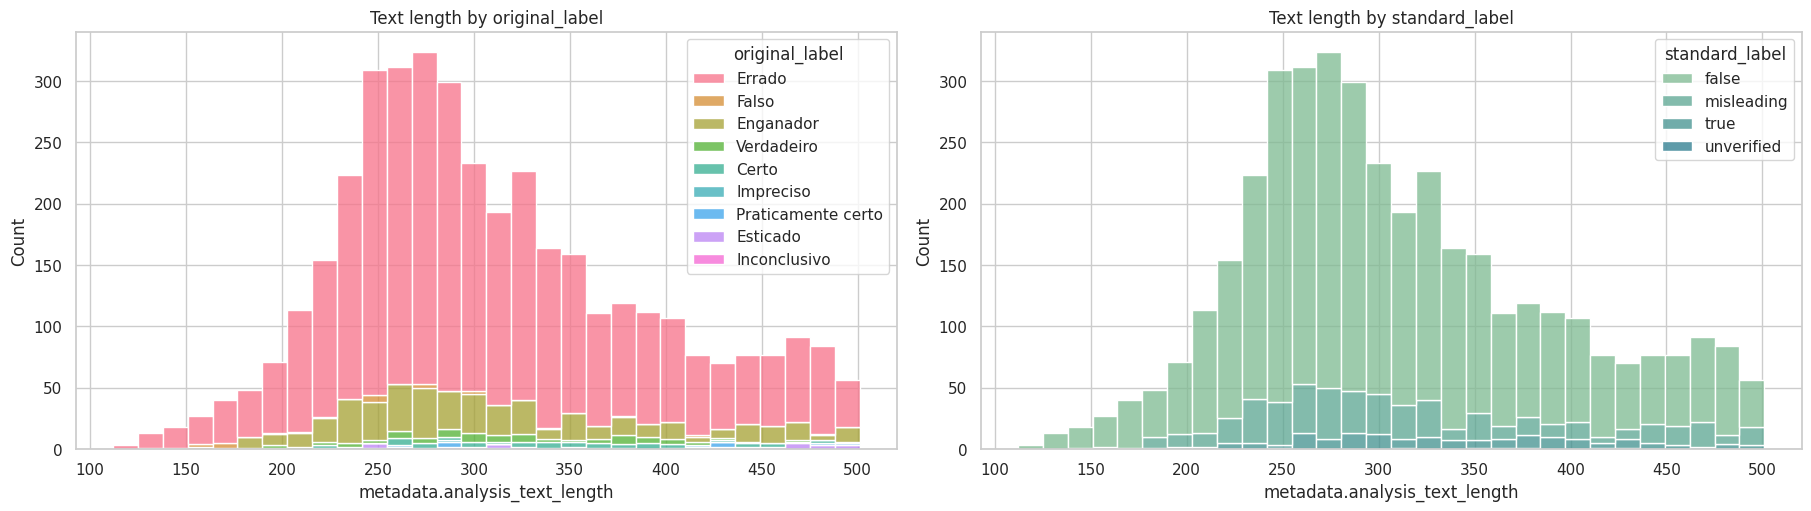

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="original_label",
    bins=30,
    multiple="stack",
    ax=axes[0],
)
axes[0].set_title("Text length by original_label")

sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="standard_label",
    bins=30,
    multiple="stack",
    ax=axes[1],
)
axes[1].set_title("Text length by standard_label")
plt.show()

## Category, topic/tag, temporal distribution, and data quality

In [6]:
topic_counts = raw_df["topics"].explode().dropna().value_counts().head(20)
tag_counts = raw_df["tags"].explode().dropna().value_counts().head(20)
category_counts = processed_df["category"].value_counts(dropna=False).head(20)

display(category_counts.rename_axis("category").reset_index(name="count"))
display(topic_counts.rename_axis("topic").reset_index(name="count"))
display(tag_counts.rename_axis("tag").reset_index(name="count"))

monthly = (
    processed_df.dropna(subset=["published_at_dt"])
    .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .size()
    .reset_index(name="count")
)
display(monthly.tail(24))

missing_fields = (
    raw_df[["title", "claim", "summary", "verdict", "rating", "published_at"]]
    .isna()
    .sum()
    .rename_axis("field")
    .reset_index(name="missing_count")
)
display(missing_fields)

display(
    processed_df.loc[
        processed_df["published_at_dt"].isna(), ["source_record_id", "title", "published_at"]
    ].head(20)
)

,category,count
0,Fact Check,3600
1,Coronavírus,174
2,Legislativas 2019,16
3,Observador/Facebook,7
4,Estado da Nação,6
5,Incêndios,4
6,Brasil,4
7,Guerra na Ucrânia,4
8,NaN,3
9,Boris Johnson,2


,topic,count


,tag,count
0,Fact Check,3870
1,Observador,3870
2,Mundo,2041
3,Sociedade,1104
4,Saúde,835
5,Europa,668
6,Política,640
7,América,614
8,Saúde Pública,597
9,Coronavírus,593


/tmp/ipykernel_2077340/1119197242.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())


,month,count
85,2024-04-01,51
86,2024-05-01,65
87,2024-06-01,64
88,2024-07-01,51
89,2024-08-01,50
90,2024-09-01,51
91,2024-10-01,53
92,2024-11-01,52
93,2024-12-01,52
94,2025-01-01,51


,field,missing_count
0,title,0
1,claim,0
2,summary,0
3,verdict,0
4,rating,0
5,published_at,0


,source_record_id,title,published_at


## Cleaning and normalization review

In [7]:
comparison = raw_df.rename(
    columns={
        "item_id": "source_record_id",
        "title": "raw_title",
        "claim": "raw_claim",
        "summary": "raw_summary",
        "published_at": "raw_published_at",
        "verdict": "raw_verdict",
    }
).merge(
    processed_df[
        [
            "source_record_id",
            "title",
            "claim_text",
            "body_text",
            "analysis_text",
            "original_label",
            "standard_label",
            "published_at",
        ]
    ],
    on="source_record_id",
    how="left",
)
display(comparison.head(15))

,source_record_id,agency_id,agency_name,spider,source_url,canonical_url,raw_title,raw_published_at,collected_at,raw_claim,raw_summary,raw_verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical,title,claim_text,body_text,analysis_text,original_label,standard_label,published_at
0,15e1dd98774b65db367eba8423dabac159c59477757006042fcae7ef08a3d918,observador,Observador,observador,https://observador.pt/factchecks/fact-check-email-dos-ficheiros-epstein-refere-que-trump-nao-gosta-de-raparigas-negras/,https://observador.pt/factchecks/fact-check-email-dos-ficheiros-epstein-refere-que-trump-nao-gosta-de-raparigas-negras,Observador,2026-02-18T16:02:11+00:00,2026-03-15T14:35:50+00:00,Um e-mail de Epstein sobre Trump disse a uma pessoa não identificada para não trazer raparigas negras. 'Trump vai estar lá. Não gosta de raparigas negras',"Alegado email enviado por Jeffrey Epstein a alguém não identificado sugere que Donald Trump não quis incluir ""raparigas negras"" em planos, porque ""não gosta...",Errado,1,pt-PT,PT,[],"[Fact Check, Observador, Donald Trump, Estados Unidos da América, América, Mundo, Caso Epstein]",[],ClaimReview,20260315T143549Z-8506cab9,2026-02-18 16:02:11+00:00,2026-03-15 14:35:50+00:00,598.560833,10,154,184,observador.pt,0.0,Observador,Um e-mail de Epstein sobre Trump disse a uma pessoa não identificada para não trazer raparigas negras. 'Trump vai estar lá. Não gosta de raparigas negras',"Alegado email enviado por Jeffrey Epstein a alguém não identificado sugere que Donald Trump não quis incluir ""raparigas negras"" em planos, porque ""não gosta...",um e-mail de epstein sobre trump disse a uma pessoa não identificada para não trazer raparigas negras. 'trump vai estar lá. não gosta de raparigas negras' a...,Errado,false,2026-02-18T16:02:11+00:00
1,2e55a8ca1d95a7280defa5a4f717e4a95f4a3d5051c4dc25ffa08d69f747860b,observador,Observador,observador,https://observador.pt/factchecks/fact-check-von-der-leyen-disse-que-a-liberdade-de-expressao-e-um-virus-e-a-censura-e-a-vacina/,https://observador.pt/factchecks/fact-check-von-der-leyen-disse-que-a-liberdade-de-expressao-e-um-virus-e-a-censura-e-a-vacina,Observador,2026-02-18T15:41:27+00:00,2026-03-15T14:35:50+00:00,"""A liberdade de expressão é um vírus e a censura é a vacina"": Ursula von der Leyen","Nas redes sociais, circula a afirmação atribuída à Presidente da Comissão Europeia. Mas terá Ursula Von der Leyen, de facto, dito tal coisa?",Errado,1,pt-PT,PT,[],"[Fact Check, Observador, Ursula von der Leyen, Mundo]",[],ClaimReview,20260315T143549Z-8506cab9,2026-02-18 15:41:27+00:00,2026-03-15 14:35:50+00:00,598.906389,10,82,140,observador.pt,0.0,Observador,"""A liberdade de expressão é um vírus e a censura é a vacina"": Ursula von der Leyen","Nas redes sociais, circula a afirmação atribuída à Presidente da Comissão Europeia. Mas terá Ursula Von der Leyen, de facto, dito tal coisa?","""a liberdade de expressão é um vírus e a censura é a vacina"": ursula von der leyen nas redes sociais, circula a afirmação atribuída à presidente da comissão...",Errado,false,2026-02-18T15:41:27+00:00
2,616a8d6d5bb3ea56ff1ad2968f9088abdef5b8e3689782aa9db8ab7ba8bfb430,observador,Observador,observador,https://observador.pt/factchecks/zuckerberg-jantou-agarrado-a-jovem-mulher-em-festa-de-epstein/,https://observador.pt/factchecks/zuckerberg-jantou-agarrado-a-jovem-mulher-em-festa-de-epstein,Observador,2026-02-18T15:31:21+00:00,2026-03-15T14:35:50+00:00,"Epstein convida Zückberg para jantar. Epstein considerou ""Wild Dinner""",Uma fotografia a circular nas redes sociais mostra uma mulher ao colo do co-fundador do Facebook. Mas apesar de o jantar do empresário e de Epstein ter acon...,Falso,2,pt-PT,PT,[],"[Fact Check, Observador, Facebook, Redes Sociais, Internet, Tecnologia, Mark Zuckerberg, Elon Musk, Caso Epstein, Estados Unidos da América, América, Mundo]",[],ClaimReview,20260

## NLP outputs

In [8]:
lemma_counts = (
    processed_df["lemmatized_text"].str.split().explode().dropna().value_counts().head(20)
)
display(lemma_counts.rename_axis("lemma").reset_index(name="count"))

entity_series = processed_df["entities"].explode().dropna()
if entity_series.empty:
    entity_df = pd.DataFrame(columns=["text", "label", "start_char", "end_char"])
else:
    entity_df = pd.json_normalize(entity_series)

display(entity_df.head(20))
display(entity_df["label"].value_counts().rename_axis("label").reset_index(name="count"))
display(processed_df[["source_record_id", "text_without_stopwords", "lemmatized_text"]].head(10))

,lemma,count
0,o,26799
1,de,17162
2,em,8255
3,ser,6864
4,que,6468
5,um,5160
6,a,4784
7,e,3594
8,não,2424
9,para,1930


,text,label,start_char,end_char
0,trump,PER,27,32
0,trump,LOC,104,109
0,jeffrey epstein,PER,181,196
0,donald trump,PER,234,246
1,von der leyen,PER,69,82
1,comissão europeia,ORG,148,165
1,von der leyen,PER,183,196
2,epstein,PER,38,45
2,facebook,MISC,159,167
3,estados unidos,LOC,17,31


,label,count
0,LOC,4533
1,PER,3492
2,ORG,1485
3,MISC,1115


,source_record_id,text_without_stopwords,lemmatized_text
0,15e1dd98774b65db367eba8423dabac159c59477757006042fcae7ef08a3d918,e-mail epstein trump disse pessoa identificada trazer raparigas negras trump gosta raparigas negras alegado email enviado jeffrey epstein alguém identificad...,um e-mail de epstein sobre trump dizer a um pessoa não identificar para não trazer rapariga negro trump ir estar lá não gostar de rapariga negro alegar emai...
1,2e55a8ca1d95a7280defa5a4f717e4a95f4a3d5051c4dc25ffa08d69f747860b,liberdade expressão vírus censura vacina ursula von der leyen redes sociais circula afirmação atribuída presidente comissão europeia terá ursula von der ley...,o liberdade de expressão ser um vírus e o censura ser o vacina ursula von der leyen em o rede social circular o afirmação atribuir a o presidente de o comis...
2,616a8d6d5bb3ea56ff1ad2968f9088abdef5b8e3689782aa9db8ab7ba8bfb430,epstein convida zückberg jantar epstein considerou wild dinner fotografia circular redes sociais mostra mulher colo co-fundador facebook apesar jantar empre...,epstein convidar zückberg para jantar epstein considerar wild dinner um fotografia a circular em o rede social mostrar um mulher a o colo de o co-fundador d...
3,90113115b8accc1c3aef715bd3353cc1dc777fa2496eda0ed5cc6350049f438e,presidente estados unidos escreveu carta ministro noruega resposta deixou muita gente andando farrapos surpresas responder carta norueguês decidiu focar-se ...,o presidente de o estados unidos escrever um carta para o primeiro ministro de o noruega mas o resposta deixar muito gente andar sobre o farrapo de surpresa...
4,e6a4165b39d4bbb60c6c10e1654c8e6ea614bc710be8124fe82d0fb104901f67,recebermos migração procura solidário concordo ideia há muitas mesquitas durante campanha presidenciais publicação redes sociais atribuiu antónio josé segur...,ser a favor de receber todo o migração que nós procura pois ser um povo solidário e não concordar com o ideia de que já haver muito mesquita durante o campa...
5,52e974c2fc1ae8d56ad1b5490e224049d81c8f6511628f970be130f4e1b0b4bb,bad bunny apanhado palco ensaiar show intervalo super bowl animado apresentação dele artista mundo ice achar eua regredir vive clima crispado conservadores ...,bad bunny ser apanhar em o palco a ensaiar para o show de o intervalo de o super bowl estar animado com o apresentação de ele ele ser o grande artista de o ...
6,f133e9b8f41e93ae2949740a5b3d93af93043325345b3e9d9820308c5d518994,partido pussies chama fascista mexe poucos dias paulo núncio abordado 2a volta eleições presidenciais publicações alegam deputado desfiliou cds-pp deixando ...,não poder estar em um partido de pussies que chamar fascista a tudo o que mexer pouco dia depois de paulo núncio ter abordar o 2a volta de o eleição preside...
7,e649b2a2be0e62f130a191df7a2ecf598ba167c9b91cf779be122b68bee9c2b3,acontece zelensky mencionado ficheiros epstein tráfico pessoas ucrânia redes sociais surgiu teoria volodymyr zelensky referido ficheiros jeffrey epstein ale...,acontecer que zelensky ser mencionar em o ficheiro de epstein em relação a o tráfico de pessoa de o ucrânia em o rede social surgir o teoria de que volodymy...
8,af8dfb71443b562ce0d8cc872b751618882ef071d28319358c0c78eaf21094bc,trump reconhece maria corina machado presidente inicia transição venezuela publicações redes sociais afirmam maría corina machado nomeada presidente venezue...,trump reconhecer maria corina machado como presidente e iniciar transição em o venezuela publicação em o rede social afirmar que maría corina machado ser no...
9,a52f70832288c31ca10e79783019a66a84d47a44b1f282f541b6ba97c113cb57,zohran mamdani surge criança fotografia epstein posts redes sociais partilhado fotografia supostamente mostra zohran mamdani criança jeffrey epstein imagem ...,zohran mamdani surgir em criança em um fotografia a o lado de epstein post em o rede social ter partilhar um fotografia que supostamente mostrar zohran mamd...


## Export processed JSONL

In [9]:
export_info = eu.export_processed_records(
    DATA_DIR,
    SPIDER,
    records=processed_records,
    selection=selection,
    snapshot_id=SNAPSHOT_ID,
)

display(
    pd.DataFrame(
        [
            {
                "snapshot_id": export_info["snapshot_id"],
                "record_count": export_info["record_count"],
                "spider_path": str(export_info["spider_path"]),
                "combined_path": str(export_info["combined_path"]),
                "manifest_path": str(export_info["manifest_path"]),
            }
        ]
    )
)

,snapshot_id,record_count,spider_path,combined_path,manifest_path
0,20260316T000212Z-observador,3910,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260316T000212Z-observador/spiders/observador.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260316T000212Z-observador/factcheck_scrape_unified.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260316T000212Z-observador/manifest.json
